# Fraud Detection — Fixed Training Notebook

Run cells top-to-bottom in a fresh kernel. This version preserves the project's features and required model artifacts while fixing kernel/path issues and preventing SMOTE leakage into the test set.

In [2]:
from pathlib import Path
import gc
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib
warnings.filterwarnings("ignore")
print("Imports successful.")


Imports successful.


In [3]:
cwd = Path.cwd()
if (cwd / "data" / "transactions.csv").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "data" / "transactions.csv").exists():
    REPO_ROOT = cwd.parent
else:
    raise FileNotFoundError("Open this notebook from the fraud-detection repository; data/transactions.csv was not found.")

DATA_PATH = REPO_ROOT / "data" / "transactions.csv"
MODEL_DIR = REPO_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Repository:", REPO_ROOT)
print("Dataset:", DATA_PATH)
print("Models:", MODEL_DIR)


Repository: c:\Users\uttam\Desktop\AI-Projects\fraud-detection
Dataset: c:\Users\uttam\Desktop\AI-Projects\fraud-detection\data\transactions.csv
Models: c:\Users\uttam\Desktop\AI-Projects\fraud-detection\models


In [4]:
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
print(df.info())
print("\nMissing values:")
display(df.isnull().sum())
print("\nStatistics:")
display(df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB
None

Missing values:


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Statistics:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
required = ["step","type","amount","nameOrig","oldbalanceOrg","newbalanceOrig","nameDest","oldbalanceDest","newbalanceDest","isFraud","isFlaggedFraud"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df.drop(["nameOrig", "nameDest"], axis=1, inplace=True)

type_encoder = LabelEncoder()
df["type"] = type_encoder.fit_transform(df["type"])
joblib.dump(type_encoder, MODEL_DIR / "type_encoder.joblib")

print("Transaction types:", list(type_encoder.classes_))
print("Saved type_encoder.joblib")


Transaction types: ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
Saved type_encoder.joblib


In [7]:
df["errorBalanceOrig"] = df["newbalanceOrig"] + df["amount"] - df["oldbalanceOrg"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]
print("Feature engineering complete.")
display(df.head())


Feature engineering complete.


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,0,0.0,9839.64
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,0,0.0,1864.28
2,1,4,181.00,181.0,0.00,0.0,0.0,1,0,0.0,181.00
3,1,1,181.00,181.0,0.00,21182.0,0.0,1,0,0.0,21363.00
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,0,0.0,11668.14


Class counts:


isFraud
0    6354407
1       8213
Name: count, dtype: int64

Class proportions:


isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

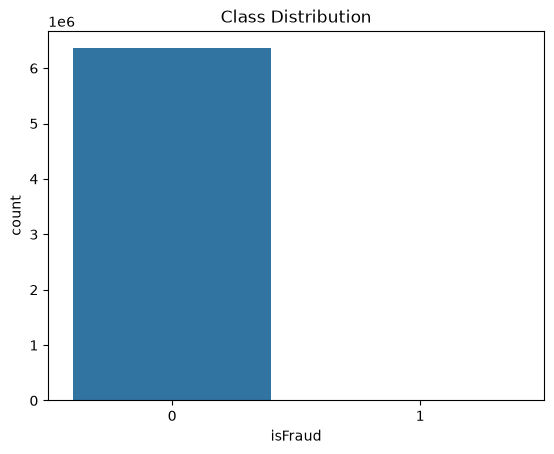

In [8]:
print("Class counts:")
display(df["isFraud"].value_counts())
print("Class proportions:")
display(df["isFraud"].value_counts(normalize=True))

sns.countplot(x="isFraud", data=df)
plt.title("Class Distribution")
plt.show()


In [9]:
X = df.drop(["isFraud", "isFlaggedFraud"], axis=1)
y = df["isFraud"]
print("Features:", list(X.columns))
print("X shape:", X.shape)


Features: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest']
X shape: (6362620, 9)


In [10]:
# FIX: split before SMOTE so the test set remains untouched.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train labels:")
display(y_train.value_counts())
print("Test labels:")
display(y_test.value_counts())


Train: (4453834, 9)  Test: (1908786, 9)
Train labels:


isFraud
0    4448085
1       5749
Name: count, dtype: int64

Test labels:


isFraud
0    1906322
1       2464
Name: count, dtype: int64

In [11]:
# SMOTE is applied ONLY to training data.
# On a multi-million-row dataset this may require substantial RAM.
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
display(y_train_res.value_counts())
print("Resampled train shape:", X_train_res.shape)
gc.collect()


After SMOTE:


isFraud
0    4448085
1    4448085
Name: count, dtype: int64

Resampled train shape: (8896170, 9)


283

In [12]:
# Keep the scaler artifact required by the Streamlit app.
# XGBoost is trained on the unscaled features, matching the original notebook.
scaler = StandardScaler()
scaler.fit(X_train_res)
joblib.dump(scaler, MODEL_DIR / "scaler.joblib")
print("Saved scaler.joblib")


Saved scaler.joblib


In [13]:
model = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_res, y_train_res)
joblib.dump(model, MODEL_DIR / "xgb_model.joblib")
print("Training complete.")
print("Saved xgb_model.joblib")


Training complete.
Saved xgb_model.joblib


In [14]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1       :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))


Confusion Matrix:
[[1906159     163]
 [      9    2455]]

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9999    1.0000   1906322
           1     0.9377    0.9963    0.9662      2464

    accuracy                         0.9999   1908786
   macro avg     0.9689    0.9981    0.9831   1908786
weighted avg     0.9999    0.9999    0.9999   1908786

Accuracy : 0.9999098903701096
Precision: 0.9377387318563789
Recall   : 0.9963474025974026
F1       : 0.966155057064148
ROC-AUC  : 0.9994996358885664


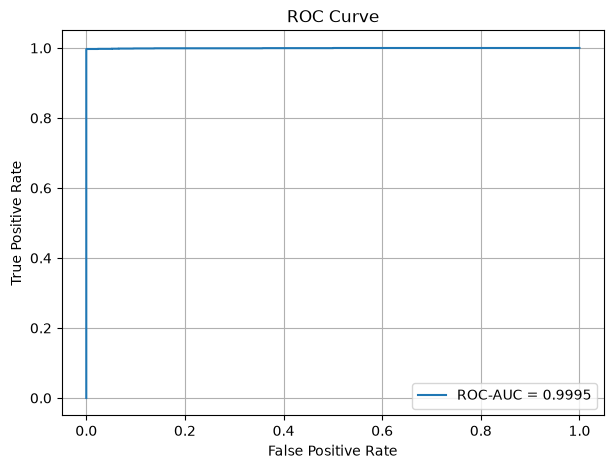

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_prob):.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


## Optional SHAP analysis

Run this only after the model artifacts have been saved. It can be expensive on a large dataset.

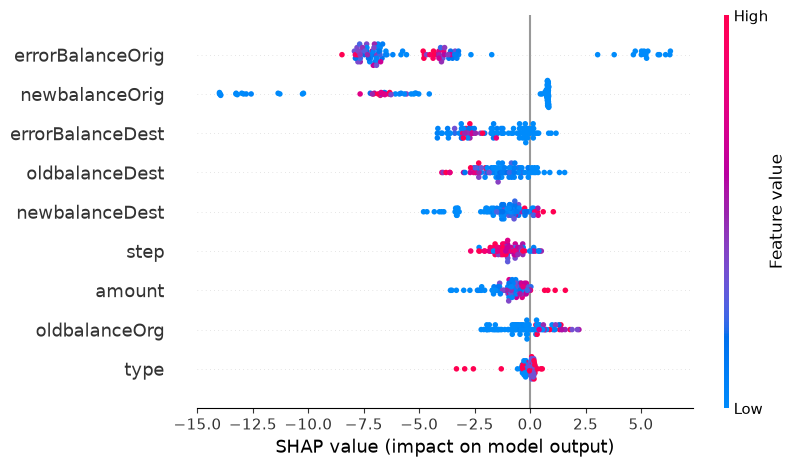

In [16]:
import shap
sample_n = min(100, len(X_test))
X_shap = X_test.iloc[:sample_n]
explainer = shap.Explainer(model)
shap_values = explainer(X_shap)
shap.plots.beeswarm(shap_values)


In [17]:
# Final artifact check for Streamlit
artifacts = [
    MODEL_DIR / "type_encoder.joblib",
    MODEL_DIR / "scaler.joblib",
    MODEL_DIR / "xgb_model.joblib",
]
for p in artifacts:
    print(p.name, "->", "OK" if p.exists() else "MISSING")

missing = [str(p) for p in artifacts if not p.exists()]
if missing:
    raise FileNotFoundError("Missing artifacts: " + ", ".join(missing))
print("\nAll three Streamlit model artifacts are ready.")


type_encoder.joblib -> OK
scaler.joblib -> OK
xgb_model.joblib -> OK

All three Streamlit model artifacts are ready.
